<a href="https://colab.research.google.com/github/Mahanteshvn/ML_LAB/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [3]:
!pip install PyPDF2
import io
import PyPDF2
from google.colab import files

# Upload the PDF file
uploaded = files.upload()

# Assuming only one file is uploaded, get its name
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  pdf_file_name = fn

if 'pdf_file_name' in locals():
    # Read the PDF file content
    pdf_file = io.BytesIO(uploaded[pdf_file_name])
    pdf_reader = PyPDF2.PdfReader(pdf_file)

    # You can now access the PDF content, for example, read all text
    # The content will not be displayed, but stored in the 'all_text' variable
    all_text = ""
    for page_num in range(len(pdf_reader.pages)):
        page = pdf_reader.pages[page_num]
        all_text += page.extract_text() + "\n"

    print(f"PDF '{pdf_file_name}' read successfully. Content available for further processing.")
    # For demonstration, you could print the first 200 characters of the content:
    # print(all_text[:200])
else:
    print("No PDF file was uploaded.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 4.8 MB/s eta 0:00:00


Saving heart.pdf to heart.pdf
User uploaded file "heart.pdf" with length 303914 bytes
PDF 'heart.pdf' read successfully. Content available for further processing.


In [5]:
generate a python code to

Original DataFrame head:
  Age Sex ChestPainType RestingBP Cholesterol FastingBS
0  40   M           ATA       140         289         0
1  49   F           NAP       160         180         0
2  37   M           ATA       130         283         0
3  48   F           ASY       138         214         0
4  54   M           NAP       150         195         0

Original DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1837 entries, 0 to 1836
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            1837 non-null   object
 1   Sex            1837 non-null   object
 2   ChestPainType  1837 non-null   object
 3   RestingBP      1837 non-null   object
 4   Cholesterol    1837 non-null   object
 5   FastingBS      1837 non-null   object
dtypes: object(6)
memory usage: 86.2+ KB

Applying encoding to categorical columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS']
  Labe

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Ensure 'df' is available from previous steps
if 'df' in locals() and isinstance(df, pd.DataFrame):
    # 1. Convert relevant columns to numeric, coercing errors
    # The previous `df.info()` indicated these were still objects.
    numeric_cols_to_convert = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS']
    for col in numeric_cols_to_convert:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Drop rows with NaN values that resulted from 'coerce' (if any)
    df.dropna(inplace=True)

    # 2. Define features (X) and target (y)
    # Assuming 'FastingBS' is the target variable (0 or 1)
    # Drop original object columns and ChestPainType_LabelEncoded to avoid redundancy
    # Keep Sex_LabelEncoded as it's a binary categorical feature
    features_to_drop = ['Sex', 'ChestPainType', 'FastingBS']
    if 'ChestPainType_LabelEncoded' in df.columns:
        features_to_drop.append('ChestPainType_LabelEncoded')

    X = df.drop(columns=[col for col in features_to_drop if col in df.columns])
    y = df['FastingBS'].astype(int) # Ensure target is integer type

    print("\nFeatures (X) head after cleaning and encoding:")
    print(X.head())
    print("\nTarget (y) head:")
    print(y.head())
    print(f"\nShape of X: {X.shape}, Shape of y: {y.shape}")

    # 3. Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print("\nData split into training and testing sets.")
    print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

    # 4. Apply Scaling to features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("Features scaled using StandardScaler.")

    # 5. Build and evaluate classification models
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
        'SVM': SVC(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42)
    }

    best_accuracy = 0
    best_model_name = ""

    print("\n--- Model Training and Evaluation ---")
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"{name} Accuracy: {accuracy:.4f}")

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model_name = name

    print(f"\nThe model with the best accuracy is {best_model_name} with an accuracy of {best_accuracy:.4f}.")

else:
    print("Error: DataFrame 'df' not found or is not a pandas DataFrame. Please run the previous data loading and preprocessing cells.")



Features (X) head after cleaning and encoding:
    Age  RestingBP  Cholesterol  Sex_LabelEncoded  ChestPainType_ASY  \
0  40.0      140.0        289.0               120                  0   
1  49.0      160.0        180.0               119                  0   
2  37.0      130.0        283.0               120                  0   
3  48.0      138.0        214.0               119                  1   
4  54.0      150.0        195.0               120                  0   

   ChestPainType_ATA  ChestPainType_ExerciseAngina  ChestPainType_N  \
0                  1                             0                0   
1                  0                             0                0   
2                  1                             0                0   
3                  0                             0                0   
4                  0                             0                0   

   ChestPainType_NAP  ChestPainType_TA  ChestPainType_Y  
0                  0              

In [10]:
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Ensure scaled data and models are available from previous steps
if 'X_train_scaled' in locals() and 'X_test_scaled' in locals() and \
   'y_train' in locals() and 'y_test' in locals() and 'models' in locals():

    print("\n--- Applying PCA for Dimensionality Reduction ---")
    # Determine the number of components. A common approach is to retain most of the variance.
    # For this example, let's pick a fixed number, e.g., 2 components or half of original features.
    # Alternatively, you can analyze explained variance ratio to pick n_components.
    n_components = min(X_train_scaled.shape[1], 5) # Let's aim for 5 components or less if features are fewer
    pca = PCA(n_components=n_components, random_state=42)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    print(f"Original number of features: {X_train_scaled.shape[1]}")
    print(f"Reduced number of features (PCA): {X_train_pca.shape[1]}")
    print(f"Explained variance ratio by {n_components} components: {pca.explained_variance_ratio_.sum():.4f}")

    print("\n--- Retraining Models with PCA-transformed Data ---")
    models_pca = {
        'Logistic Regression (PCA)': LogisticRegression(random_state=42, solver='liblinear'),
        'SVM (PCA)': SVC(random_state=42),
        'Random Forest (PCA)': RandomForestClassifier(random_state=42)
    }

    best_accuracy_pca = 0
    best_model_name_pca = ""

    for name, model in models_pca.items():
        model.fit(X_train_pca, y_train)
        y_pred_pca = model.predict(X_test_pca)
        accuracy_pca = accuracy_score(y_test, y_pred_pca)
        print(f"{name} Accuracy: {accuracy_pca:.4f}")

        if accuracy_pca > best_accuracy_pca:
            best_accuracy_pca = accuracy_pca
            best_model_name_pca = name

    print(f"\nThe model with the best accuracy after PCA is {best_model_name_pca} with an accuracy of {best_accuracy_pca:.4f}.")

    # Compare with previous best model without PCA
    # Assuming 'best_accuracy' and 'best_model_name' are available from the previous cell's execution
    if 'best_accuracy' in locals() and 'best_model_name' in locals():
        print("\n--- Comparison (PCA vs. No PCA) ---")
        print(f"Best model without PCA: {best_model_name} with accuracy: {best_accuracy:.4f}")
        print(f"Best model with PCA: {best_model_name_pca} with accuracy: {best_accuracy_pca:.4f}")
        if best_accuracy_pca > best_accuracy:
            print("PCA improved the best model's accuracy!")
        elif best_accuracy_pca < best_accuracy:
            print("PCA slightly reduced the best model's accuracy, but may offer computational benefits.")
        else:
            print("PCA had no significant impact on the best model's accuracy.")
else:
    print("Error: Required variables (scaled data or models) not found. Please ensure previous cells were executed successfully.")



--- Applying PCA for Dimensionality Reduction ---
Original number of features: 11
Reduced number of features (PCA): 5
Explained variance ratio by 5 components: 0.8117

--- Retraining Models with PCA-transformed Data ---
Logistic Regression (PCA) Accuracy: 0.7935
SVM (PCA) Accuracy: 0.7935
Random Forest (PCA) Accuracy: 0.7391

The model with the best accuracy after PCA is Logistic Regression (PCA) with an accuracy of 0.7935.

--- Comparison (PCA vs. No PCA) ---
Best model without PCA: Logistic Regression with accuracy: 0.7935
Best model with PCA: Logistic Regression (PCA) with accuracy: 0.7935
PCA had no significant impact on the best model's accuracy.


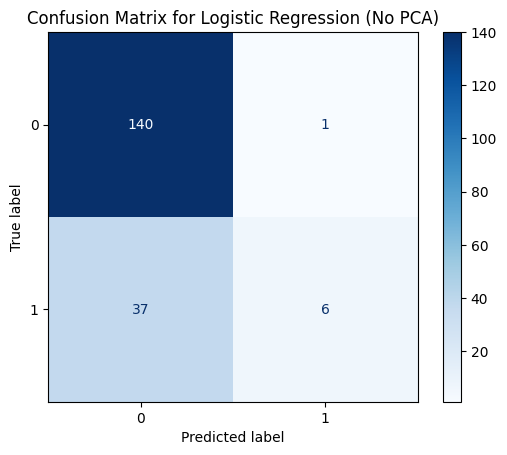

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix for the best model without PCA (Logistic Regression)
if 'Logistic Regression' in models and 'y_test' in locals() and 'X_test_scaled' in locals():
    best_model_no_pca = models['Logistic Regression']
    y_pred_no_pca = best_model_no_pca.predict(X_test_scaled)
    cm_no_pca = confusion_matrix(y_test, y_pred_no_pca, labels=best_model_no_pca.classes_)

    disp_no_pca = ConfusionMatrixDisplay(confusion_matrix=cm_no_pca, display_labels=best_model_no_pca.classes_)
    disp_no_pca.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix for Logistic Regression (No PCA)')
    plt.show()
else:
    print("Error: Required variables or model not found for non-PCA confusion matrix.")


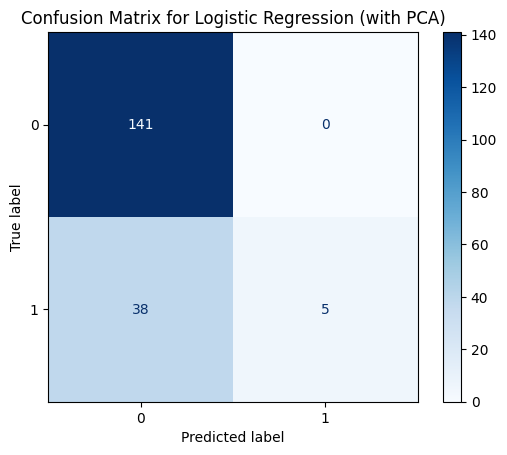

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix for the best model with PCA (Logistic Regression PCA)
if 'Logistic Regression (PCA)' in models_pca and 'y_test' in locals() and 'X_test_pca' in locals():
    best_model_pca = models_pca['Logistic Regression (PCA)']
    y_pred_pca = best_model_pca.predict(X_test_pca)
    cm_pca = confusion_matrix(y_test, y_pred_pca, labels=best_model_pca.classes_)

    disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=best_model_pca.classes_)
    disp_pca.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix for Logistic Regression (with PCA)')
    plt.show()
else:
    print("Error: Required variables or model not found for PCA confusion matrix.")
